# Reachy System 2 — walkthrough

<div style="text-align: center">

<img src="docs/system2_architecture.png" alt="System 2 architecture" style="max-width: 100%; width: 1100px;" />

</div>


## Setup

- Repo root on `sys.path`; load `.env`.
- Restart kernel after editing `reachy_system2` code.


In [1]:
from pathlib import Path
import sys
import os

def find_repo_root() -> Path:
    """Walk upward until we find `.git` or a reachy_pollen-style root."""
    p = Path.cwd().resolve()
    for parent in [p, *p.parents]:
        if (parent / ".git").exists():
            return parent
        if (parent / "reachy_system2").is_dir() and (parent / "README.md").exists():
            return parent
    return p


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from dotenv import load_dotenv

load_dotenv(REPO_ROOT / ".env")
print("REPO_ROOT =", REPO_ROOT)

REPO_ROOT = /home/nikolaraicevic/Workspace/Internal/Reachy_Pollen


## Run parameters

`REACHY_HOST`, `SYSTEM2_TASK`, optional `SYSTEM2_LABELS` (empty → LLM infers labels), `SETTLING_S`.


In [2]:
import os

HOST = os.environ.get("REACHY_HOST", "192.168.10.172")
_raw_labels = (os.environ.get("SYSTEM2_LABELS") or "").strip()
LABELS = [s.strip() for s in _raw_labels.split(",") if s.strip()] if _raw_labels else []
TASK = os.environ.get("SYSTEM2_TASK", "Describe the scene and suggest a safe motion.")
SETTLING_S = float(os.environ.get("SETTLING_S", "0.75"))

print("HOST:", HOST)
print("LABELS (empty → inferred from TASK in Sections 1 & 5):", LABELS or "(infer)")
print("TASK:", TASK)
print("SETTLING_S:", SETTLING_S)


HOST: 192.168.10.172
LABELS (empty → inferred from TASK in Sections 1 & 5): ['cylindrical tomato soup can', 'metal bowl', 'table']
TASK: Pick up the tomato soup can and place it into the metal bowl without hitting the table.
SETTLING_S: 0.75


## Section 1 — Perception

1. `infer_tracked_labels(TASK)` if `LABELS` empty.
2. `set_tracked_labels` → `start()` → `snapshot()`.

`PerceptionSnapshot`: `rgb`, `depth_viz_rgb` (torso depth colormap → LLM), `annotated_rgb` (viz only), `scene`, `objects`.

§5 uses `snapshot_until_tracked_objects()` (retries until labels match).


In [3]:
from reachy2_sdk import ReachySDK

reachy = ReachySDK(HOST)
ic = reachy.is_connected() if callable(getattr(reachy, "is_connected", None)) else bool(reachy.is_connected)
assert ic, "Not connected — check REACHY_HOST and network."
assert reachy.cameras is not None and reachy.cameras.depth is not None, (
    "Depth camera required for Perception extrinsics (see greengrocer tutorial)."
)
print("Reachy connected; depth camera present.")

Local API version (1.0.21) is different from the robot's API version (1.0.19).
Some features may not work properly.
Please update the reachy2_core image on the robot to ensure compatibility, or downgrade your local reachy2_sdk package.
This Reachy is in REAL mode :
⚠️  Be careful, you're controlling the PHYSICAL Reachy.



Reachy connected; depth camera present.


In [4]:
from reachy_system2.perception import System2Perception
from reachy_system2.reasoning import ReasoningClient

perception = System2Perception(reachy)
reasoning = ReasoningClient()

labels_for_perception = LABELS
if not labels_for_perception:
    labels_for_perception = reasoning.infer_tracked_labels(TASK)
    print("Inferred labels:", labels_for_perception)

perception.set_tracked_labels(labels_for_perception)
perception.start(visualize=False)

snap = perception.snapshot(settling_s=SETTLING_S)
rgb = snap.rgb
annotated_rgb = snap.annotated_rgb
depth_viz_rgb = snap.depth_viz_rgb
scene = snap.scene
detected_objects = snap.objects

print(scene)
print("depth_viz_rgb:", None if depth_viz_rgb is None else depth_viz_rgb.shape)
print("RGB shape:", rgb.shape, "dtype:", rgb.dtype)
print("Detected objects (structured):", len(detected_objects))


/home/nikolaraicevic/Workspace/Internal/Reachy_Pollen/reachy2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Already connected to Reachy.
This Reachy is in REAL mode :
⚠️  Be careful, you're controlling the PHYSICAL Reachy.

Could not find image processor class in the image processor config or the model config. Loading based on pattern matching with the model's feature extractor configuration. Please open a PR/issue to update `preprocessor_config.json` to use `image_processor_type` instead of `feature_extractor_type`. This warning will be removed in v4.40.


DETECTED_OBJECTS (robot frame, meters; +Y = robot's left):

- cylindrical tomato soup can: x=0.4611, y=-0.1694, z=-0.3321 detection_score=0.101 temporal_score=0.150
- cylindrical tomato soup can: x=0.4611, y=-0.1694, z=-0.3321 detection_score=0.101 temporal_score=0.150
- table: x=0.4675, y=-0.0167, z=-0.4245 detection_score=0.198 temporal_score=0.150
- metal bowl: x=0.5185, y=0.1752, z=-0.3516 detection_score=0.103 temporal_score=0.150
depth_viz_rgb: (720, 1280, 3)
RGB shape: (720, 1280, 3) dtype: uint8
Detected objects (structured): 4


### Visualize snapshot

RGB, annotated detections, depth colormap (if available).


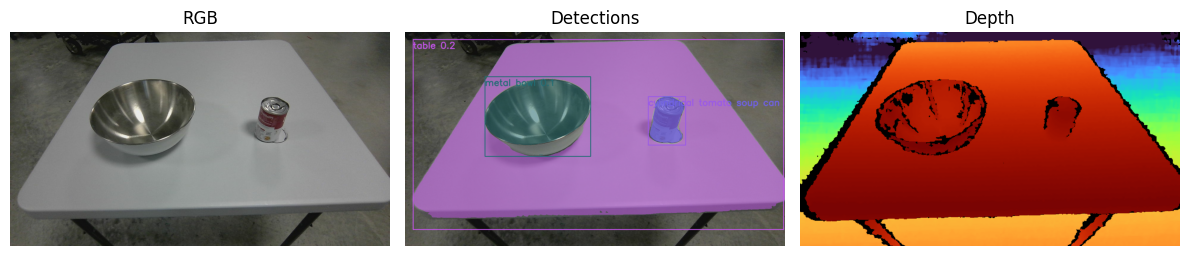

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [ ]:
try:
    import matplotlib.pyplot as plt

    panels = [("RGB", rgb), ("Detections", annotated_rgb)]
    if depth_viz_rgb is not None:
        panels.append(("Depth", depth_viz_rgb))
    fig, axes = plt.subplots(1, len(panels), figsize=(4 * len(panels), 4))
    if len(panels) == 1:
        axes = [axes]
    for ax, (title, im) in zip(axes, panels):
        ax.imshow(im)
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("matplotlib skipped:", e)


## Section 2 — Reasoning

`generate_plan`: TASK, PERCEPTION (`scene`), VISION_LABELS, ROBOT_STATE (TCP), **RGB_IMAGE**, **DEPTH_IMAGE** (`depth_viz_rgb`).

Smoke-test cell below (optional).


In [ ]:
import os

from openai import OpenAI

client = OpenAI()

response = client.chat.completions.create(
    model=os.environ.get("OPENAI_MODEL", "gpt-4o"),
    messages=[
        {"role": "user", "content": "Write a one-sentence bedtime story about a unicorn."}
    ],
    max_tokens=50,
)
print(response.choices[0].message.content)


In [ ]:
import json

from reachy_system2.reasoning import ReasoningClient
from reachy_system2.robot_context import format_end_effector_context_for_llm

reasoning = ReasoningClient()
ee_context = format_end_effector_context_for_llm(reachy)
print(ee_context)

plan = reasoning.generate_plan(
    TASK,
    scene,
    rgb,
    depth_viz_rgb=depth_viz_rgb,
    tracked_labels=labels_for_perception,
    robot_context=ee_context,
)
print(json.dumps(plan, indent=2)[:8000])


## Section 3 — Executor

`validate_subtask_bounds` then `run_subtask` on subtask 0 (`dry_run=True` = no motion).


In [ ]:
from reachy_system2.executor import ActionExecutor

executor = ActionExecutor(reachy)
sub0 = plan["subtasks"][0]

print("validate:", executor.validate_subtask_bounds(sub0))
print("run (dry_run):", executor.run_subtask(sub0, wait=True, dry_run=True))


## Section 4 — Verification

`verify_execution`: PERCEPTION_AFTER + RGB/depth before & after subtask.


In [ ]:
import json

rgb_before = rgb
snap2 = perception.snapshot(settling_s=SETTLING_S)
rgb2, scene2 = snap2.rgb, snap2.scene
depth_viz_before = depth_viz_rgb
depth_viz_after = snap2.depth_viz_rgb

ver = reasoning.verify_execution(
    goal=TASK,
    subtask_description=sub0.get("description", ""),
    scene_after=scene2,
    rgb_after=rgb2,
    rgb_before=rgb_before,
    depth_viz_after=depth_viz_after,
    depth_viz_before=depth_viz_before,
)
print(json.dumps(ver, indent=2))


## Section 5 — `run_closed_loop`

Same as CLI: infer labels → `snapshot_until_tracked_objects` → plan → per subtask: confirm → execute → verify.

Vision verify only on **grasp / approach / place** subtasks (lift & transit are skipped). On FAILED: correction → re-verify; else minimal recovery (≤2 steps), up to `SYSTEM2_MAX_VERIFY_RETRIES`.

- `perception.stop()` first (loop creates its own perception).
- `confirm_steps=True`: type `y` when prompted (including recovery subtasks).
- Logs: `reachy_system2/runs/<timestamp>/` (`perception_after_subtask_*`, `replan_failure_subtask_*`, `verify_*`).


In [ ]:
from reachy_system2.main import run_closed_loop

perception.stop()

run_closed_loop(
    reachy=reachy,
    task=TASK,
    labels=LABELS or None,  
    settling_s=SETTLING_S,
    confirm_steps=True,
    dry_run=False,  
    log_runs=True,
    robot_host=HOST,
)
